In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [2]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Return Rate\data\Copy of delivery_fee_movement.csv"
df = pd.read_csv(file_path)

In [3]:
df.head()

,date,Day of week,City,restaurant_id,Distance(KM),DeliveryFee($),Base Fee,Surge Fee
0,3/1/2025,Saturday,Omaha,0,0,4.25,2.0,2.25
1,3/1/2025,Saturday,Omaha,0,3,4.75,2.5,2.25
2,3/1/2025,Saturday,Omaha,0,5,5.75,3.5,2.25
3,3/1/2025,Saturday,Omaha,0,6,6.25,4.0,2.25
4,3/1/2025,Saturday,Omaha,0,8,7.25,5.0,2.25


In [15]:
df["Distance(KM)"] = df["Distance(KM)"].astype(str)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 217222 entries, 0 to 217221
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            217222 non-null  str    
 1   Day of week     217222 non-null  str    
 2   City            217222 non-null  str    
 3   restaurant_id   217222 non-null  int64  
 4   Distance(KM)    217222 non-null  str    
 5   DeliveryFee($)  217222 non-null  float64
 6   Base Fee        217222 non-null  float64
 7   Surge Fee       217222 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 13.3 MB


In [17]:
df.describe()

,restaurant_id,DeliveryFee($),Base Fee,Surge Fee
count,217222.000000,217222.000000,217222.000000,217222.000000
mean,500.457293,4.840096,3.069721,1.770374
std,289.121652,1.808948,1.155798,1.528800
min,0.000000,2.000000,2.000000,0.000000
25%,250.000000,3.500000,2.000000,0.250000
50%,501.000000,5.000000,2.500000,2.000000
75%,752.000000,6.000000,4.000000,3.000000
max,999.000000,12.000000,5.500000,6.500000


In [18]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

date: 31
Day of week: 7
City: 2
Distance(KM): 10


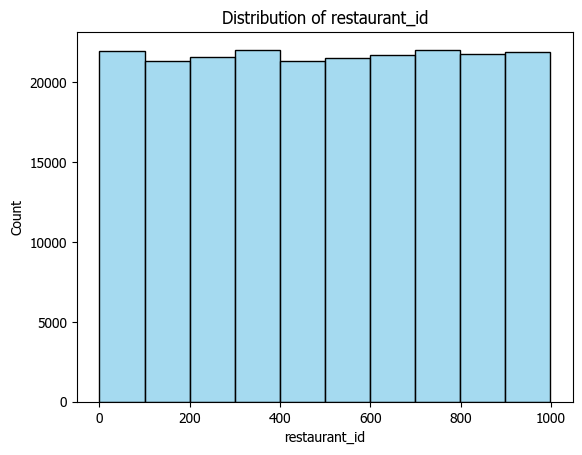

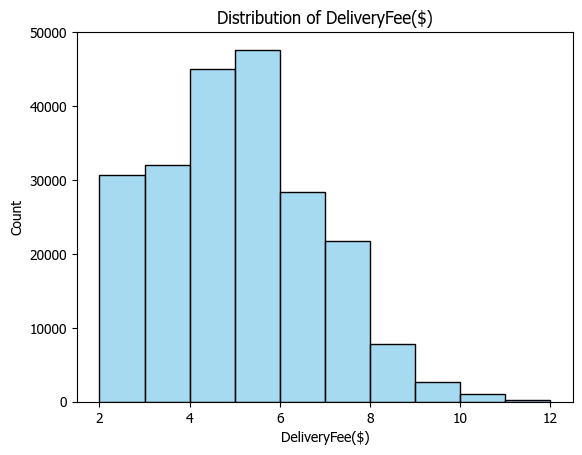

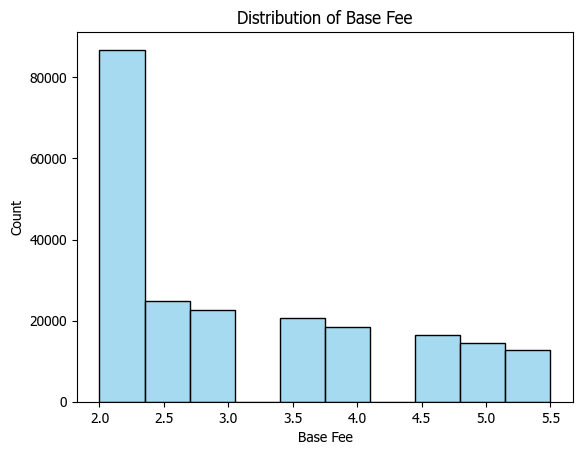

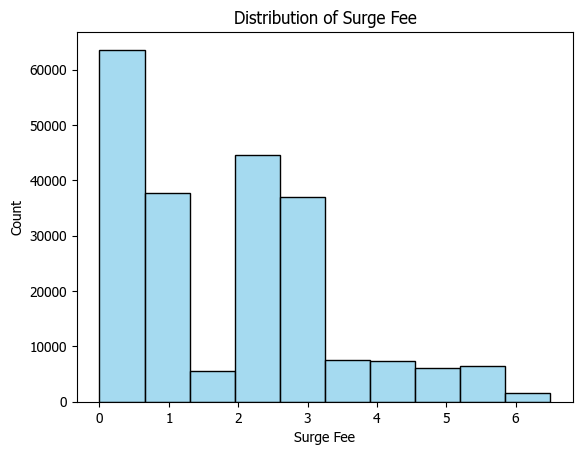

In [19]:
for col in df.select_dtypes(include="number").columns:
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=10, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

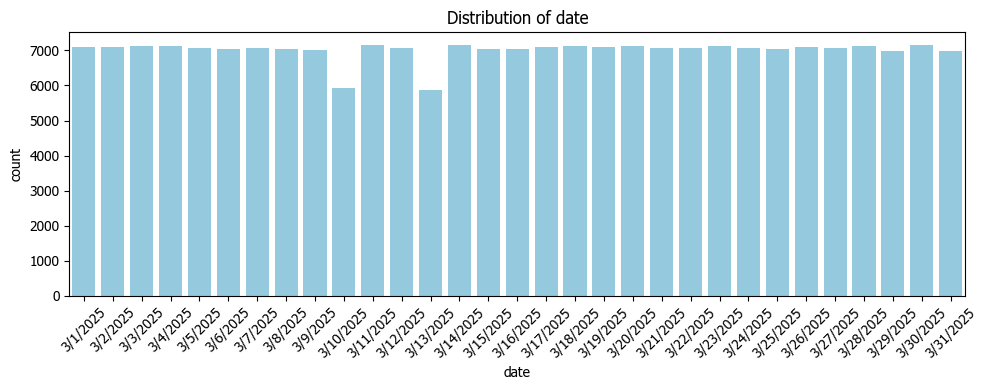

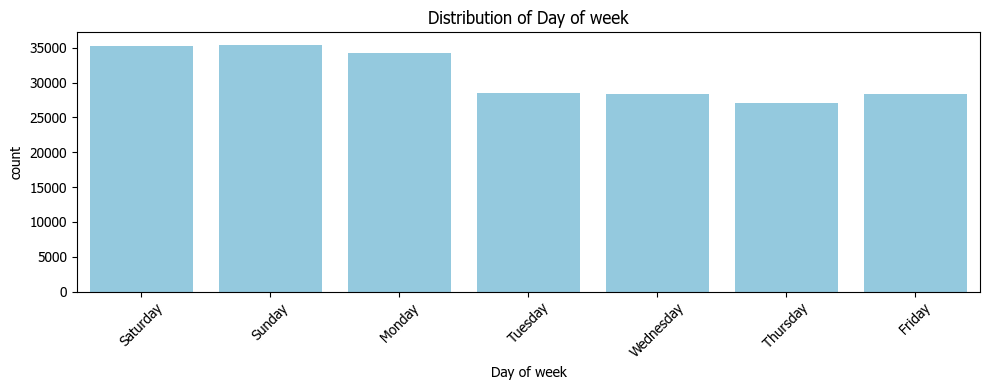

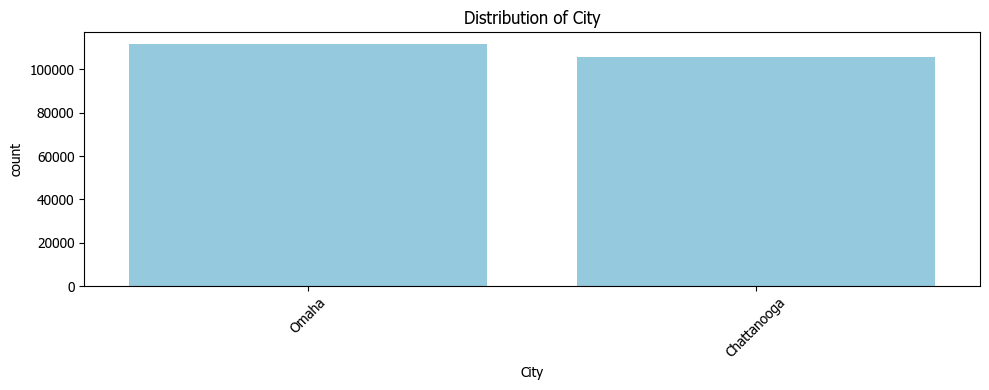

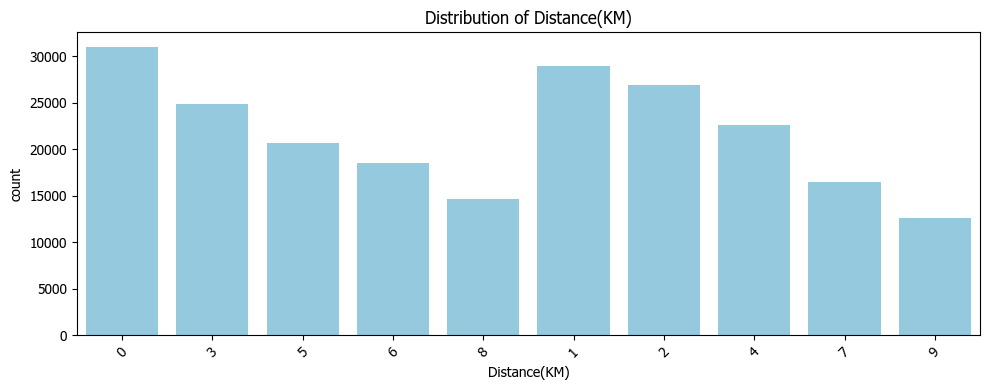

In [20]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]).columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [26]:
print("--- รายงานผลการทดสอบ Normality (ความเป็นเส้นโค้งปกติ) ---")
print("สมมติฐานหลัก (H0): ข้อมูลมีการแจกแจงเป็นเส้นโค้งปกติ (Normal Distribution)\n")

# วนลูปทดสอบเฉพาะคอลัมน์ที่เป็นตัวเลข
for col in df.select_dtypes(include="number").columns.drop(["restaurant_id", "DeliveryFee($)", "Base Fee"]):
    # ตัดค่า null ออกก่อนทดสอบ
    data_clean = df[col].dropna()

    # ตรวจสอบจำนวนข้อมูลเบื้องต้น
    if len(data_clean) < 3:
        continue

    # ใช้ D'Agostino's K-squared Test (เหมาะสำหรับข้อมูลขนาดใหญ่)
    stat, p_value = stats.normaltest(data_clean)

    # คำนวณค่า Kurtosis (ความโด่ง) เพิ่มเติมเพื่อใช้เขียนคู่กับ Skewness
    kurt_val = data_clean.kurtosis()
    skew_val = data_clean.skew()

    print(f"คอลัมน์: {col}")
    print(f"  - ค่า Skewness (ความเบ้): {skew_val:.4f}")
    print(f"  - ค่า Kurtosis (ความโด่ง): {kurt_val:.4f}")
    print(f"  - p-value จาก Normality Test: {p_value:.4e}")

    # แปลผลทางสถิติด้วยค่า p-value (Alpha = 0.05)
    if p_value > 0.05:
        print(
            "  -> สรุปผล: ยอมรับ H0 ข้อมูลมี การแจกแจงเป็นปกติ (Normal Distribution) อย่างมีนัยสำคัญ"
        )
    else:
        print(
            "  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ"
        )
    print("-" * 65)

--- รายงานผลการทดสอบ Normality (ความเป็นเส้นโค้งปกติ) ---
สมมติฐานหลัก (H0): ข้อมูลมีการแจกแจงเป็นเส้นโค้งปกติ (Normal Distribution)

คอลัมน์: Surge Fee
  - ค่า Skewness (ความเบ้): 0.6843
  - ค่า Kurtosis (ความโด่ง): -0.0950
  - p-value จาก Normality Test: 0.0000e+00
  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ
-----------------------------------------------------------------


In [27]:
import pandas as pd
import scipy.stats as stats

# 1. คัดแยกประเภทคอลัมน์อัตโนมัติ
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns.drop(["date", "City"])
numeric_cols = df.select_dtypes(include=["number"]).columns.drop(["restaurant_id", "DeliveryFee($)", "Base Fee"])

print("==================================================================")
# สแกนหาความแปรปรวนแบบจับคู่ตัดขวาง
print("📢 เริ่มการทดสอบ Levene's Test ทุกคู่ปัจจัย (X-Categorical vs Y-Numeric)")
print("==================================================================\n")

# วนลูปตามตัวแปรตาม (Y) ที่เป็นตัวเลขก่อน
for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ตัวแปรตาม Y: {y_col}]")
    print("=" * 66)

    # วนลูปตามตัวแปรต้น (X) ที่เป็นข้อความมาจับคู่
    for x_col in categorical_cols:
        # ข้ามคอลัมน์วันที่เพื่อป้องกันข้อผิดพลาดเชิงสถิติ
        if "date" in x_col.lower():
            continue

        # จัดกลุ่มข้อมูล Y ตามประเภทของ X และตัดค่าว่างออก
        groups = [
            group[y_col].dropna()
            for name, group in df.groupby(x_col)
            if len(group[y_col].dropna()) > 0
        ]

        # เช็คเงื่อนไขความสมบูรณ์ของกลุ่มย่อย
        if len(groups) < 2:
            print(
                f"⚠️ คู่ [{x_col}] vs [{y_col}]: กลุ่มย่อยมีน้อยกว่า 2 กลุ่ม ไม่สามารถทดสอบได้"
            )
            print("-" * 66)
            continue

        # รันสถิติ Levene's Test
        stat, p_value = stats.levene(*groups)

        print(f" 👉 ตัวแปรต้น (X): {x_col}")
        print(f"    - ค่าสถิติ (Statistic): {stat:.4f}")
        print(f"    - p-value: {p_value:.4e}")

        # แปลผลลัพธ์เพื่อนำไปเลือกโมเดลต่อ
        if p_value > 0.05:
            print(
                "    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ (ผ่านเกณฑ์ ใช้ ANOVA / t-test ปกติ)"
            )
        else:
            print(
                "    -> สรุปผล: p < 0.05 ความแปรปรวน 'ไม่เท่ากัน' ❌ (ต้องเลี่ยงไปใช้ Welch's ANOVA / Welch's t-test)"
            )
        print("-" * 66)
    print("\n" + "=" * 66 + "\n")

📢 เริ่มการทดสอบ Levene's Test ทุกคู่ปัจจัย (X-Categorical vs Y-Numeric)

🎯 [วิเคราะห์ตัวแปรตาม Y: Surge Fee]
 👉 ตัวแปรต้น (X): Day of week
    - ค่าสถิติ (Statistic): 544.8803
    - p-value: 0.0000e+00
    -> สรุปผล: p < 0.05 ความแปรปรวน 'ไม่เท่ากัน' ❌ (ต้องเลี่ยงไปใช้ Welch's ANOVA / Welch's t-test)
------------------------------------------------------------------
 👉 ตัวแปรต้น (X): Distance(KM)
    - ค่าสถิติ (Statistic): 218.1218
    - p-value: 0.0000e+00
    -> สรุปผล: p < 0.05 ความแปรปรวน 'ไม่เท่ากัน' ❌ (ต้องเลี่ยงไปใช้ Welch's ANOVA / Welch's t-test)
------------------------------------------------------------------




In [28]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ Surge Fee แบ่งตาม Day of week")
print("=========================================================")
desc_stats = df.groupby('Day of week')['Surge Fee'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราวในตารางแรก
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม Day of week
groups_data = [group['Surge Fee'].values for name, group in df.groupby('Day of week')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['Surge Fee_RANK'] = df['Surge Fee'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับ
    mean_ranks = df.groupby('Day of week')['Surge Fee_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks (พร้อมปรับ p-value ด้วยสถิติ)
    mc = MultiComparison(df['Surge Fee_RANK'], df['Day of week'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อหาความต่างรายคู่
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่มีความเชื่อมโยงกัน (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายตัวอักษรทางสถิติ (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์ที่รวมเอาคุณสมบัติสำหรับเขียนรายงานไว้ด้วยกัน
    rank_summary = df.groupby('Day of week').agg({'Surge Fee': 'median', 'Surge Fee_RANK': 'mean'}).reset_index()
    rank_summary['Day of week_STR'] = rank_summary['Day of week'].astype(str)
    rank_summary['Group Sign'] = rank_summary['Day of week_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='Surge Fee_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['Day of week', 'Surge Fee', 'Surge Fee_RANK', 'Group Sign']]
    rank_summary.columns = ['Day of week Status (Day of week)', 'Median Surge Fee', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median Surge Fee':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างชั่วคราวทิ้ง
    df.drop(columns=['Surge Fee_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ Surge Fee แบ่งตาม Day of week
             count mean  std  min median   max
Day of week                                   
Saturday     35231 2.19 1.66  0.0   2.25  6.50
Friday       28423 1.83 1.63  0.0   2.00  6.00
Sunday       35433 1.96 1.41  0.0   2.00  5.50
Wednesday    28354 1.52 1.50  0.0   2.00  5.25
Thursday     27119 1.72 1.53  0.0   2.00  5.00
Monday       34223 1.47 1.34  0.0   1.00  5.00
Tuesday      28439 1.62 1.48  0.0   1.00  5.75


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-Wallis  5,671.0442  0.0000

p-value ของ Kruskal-Wallis คือ: 0.0000

 3. Post-hoc Analysis (Dunn's test) & Group Letters
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Day of week Status (Day of week) Median Surge Fee  Mean Rank Statistical Group
Rank (Mean Rank มากส

In [29]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ Surge Fee แบ่งตาม Distance(KM)")
print("=========================================================")
desc_stats = df.groupby('Distance(KM)')['Surge Fee'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราวในตารางแรก
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม Distance(KM)
groups_data = [group['Surge Fee'].values for name, group in df.groupby('Distance(KM)')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['Surge Fee_RANK'] = df['Surge Fee'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับ
    mean_ranks = df.groupby('Distance(KM)')['Surge Fee_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks (พร้อมปรับ p-value ด้วยสถิติ)
    mc = MultiComparison(df['Surge Fee_RANK'], df['Distance(KM)'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อหาความต่างรายคู่
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่มีความเชื่อมโยงกัน (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายตัวอักษรทางสถิติ (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์ที่รวมเอาคุณสมบัติสำหรับเขียนรายงานไว้ด้วยกัน
    rank_summary = df.groupby('Distance(KM)').agg({'Surge Fee': 'median', 'Surge Fee_RANK': 'mean'}).reset_index()
    rank_summary['Distance(KM)_STR'] = rank_summary['Distance(KM)'].astype(str)
    rank_summary['Group Sign'] = rank_summary['Distance(KM)_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='Surge Fee_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['Distance(KM)', 'Surge Fee', 'Surge Fee_RANK', 'Group Sign']]
    rank_summary.columns = ['Distance(KM) Status (Distance(KM))', 'Median Surge Fee', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median Surge Fee':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างชั่วคราวทิ้ง
    df.drop(columns=['Surge Fee_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ Surge Fee แบ่งตาม Distance(KM)
              count mean  std  min median  max
Distance(KM)                                  
0             31000 1.95 1.61  0.0   2.00  6.5
1             28908 1.92 1.59  0.0   2.00  6.5
2             26911 1.89 1.58  0.0   2.00  6.5
3             24848 1.85 1.57  0.0   2.00  6.5
4             22644 1.80 1.54  0.0   2.00  6.5
5             20666 1.72 1.51  0.0   1.75  6.5
6             18515 1.66 1.47  0.0   1.50  6.5
7             16484 1.57 1.41  0.0   1.25  6.5
8             14602 1.48 1.35  0.0   1.00  6.5
9             12644 1.35 1.24  0.0   1.00  6.5


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-Wallis  2,600.9915  0.0000

p-value ของ Kruskal-Wallis คือ: 0.0000

 3. Post-hoc Analysis (Dunn's test) & Group Letters
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------

In [30]:
df["Distance(KM)"] = df["Distance(KM)"].astype(int)

In [31]:
# 1. ระบุลิสต์ตัวแปรที่ต้องการคำนวณ
num_vars = ['Distance(KM)','DeliveryFee($)', 'Base Fee', 'Surge Fee']

# ลบแถวที่มีค่าว่าง (NaN) เฉพาะในกลุ่มตัวแปรเหล่านี้ เพื่อให้ Matrix สมบูรณ์
df_clean = df[num_vars].dropna()


# --- ส่วนที่ 1: คำนวณตารางค่า r มาตรฐาน ---
spearman_matrix = pd.DataFrame(index=num_vars, columns=num_vars)
# --- ส่วนที่ 2: คำนวณตารางค่า R-Squared (%) ---
r2_percentage_matrix = pd.DataFrame(index=num_vars, columns=num_vars)

# ลูปจับคู่ตัวแปรวิ่งชนกันทุกคู่เพื่อคำนวณค่าทางสถิติ
for col1 in num_vars:
    for col2 in num_vars:
        if col1 == col2:
            spearman_matrix.loc[col1, col2] = "1.00"
            r2_percentage_matrix.loc[col1, col2] = "100.0%"
        else:
            # คำนวณค่า r และ p-value ด้วย Spearman's Rho
            r, p = stats.spearmanr(df_clean[col1], df_clean[col2])
            
            # คำนวณค่า R-Squared เป็นเปอร์เซ็นต์ (r^2 * 100)
            r2_pct = (r ** 2) * 100
            
            # หาดอกจันตามระดับ p-value
            stars = ""
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            
            # บันทึกค่าลงในตาราง r ปกติ
            spearman_matrix.loc[col1, col2] = f"{r:.2f}{stars}"
            
            # บันทึกค่าลงในตาราง เปอร์เซ็นต์อธิบายความผันแปร (R-squared %)
            r2_percentage_matrix.loc[col1, col2] = f"{r2_pct:.2f}%{stars}"

print("=========================================================")
print(" แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)")
print("=========================================================")
print("คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)")
print("---------------------------------------------------------")
print(spearman_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001")
print("=========================================================\n")

print("=========================================================")
print(" แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)")
print("=========================================================")
print("คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง")
print("---------------------------------------------------------")
print(r2_percentage_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001 (อิงตามนัยสำคัญของค่า r)")
print("=========================================================")

 แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)
คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)
---------------------------------------------------------
               Distance(KM) DeliveryFee($)  Base Fee Surge Fee
Distance(KM)           1.00        0.52***   0.97***  -0.10***
DeliveryFee($)      0.52***           1.00   0.54***   0.75***
Base Fee            0.97***        0.54***      1.00  -0.10***
Surge Fee          -0.10***        0.75***  -0.10***      1.00
---------------------------------------------------------
หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001

 แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)
คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง
---------------------------------------------------------
               Distance(KM) DeliveryFee($)   Base Fee  Surge Fee
Distance(KM)         100.0%      26.87%***  94.26%***   1.07%***
DeliveryFee($)    26.87%***         100.0%  28.78%***  56.00%***
Base Fee 